# Project 3. EDA. Data Preprocessing & Future Engineering 

In [1]:
# Load the libraries

import time
import re
import ast

import pandas as pd
import numpy as np
import category_encoders as ce
from collections import Counter

from scipy import stats
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import ensemble
from sklearn.feature_selection import SelectKBest, f_classif, f_regression, chi2
from sklearn import metrics

import statsmodels.api as sm
from statsmodels import stats as sms

import matplotlib.pyplot as plt
import seaborn as sns

from geopy.geocoders import Nominatim

## Problem Statement

The dataset contains 515,000 hotel reviews across Europe, with the goal of predicting hotel ratings on Booking.com based on various features such as reviewer feedback, hotel characteristics, and geographical data. The challenge lies in preprocessing the dataset, handling missing values, and engineering features to improve the predictive performance of a machine learning model, while ensuring the model generalizes well to unseen data.

**Business Task**

Develop a machine learning model to accurately predict hotel ratings on Booking.com, enabling better recommendations for users and insights for hotel management. The model should leverage the available review data to provide reliable predictions, minimizing prediction errors as measured by the Mean Absolute Percentage Error (MAPE).

**Technical Task**

As a data scientist,
1. `Explore and preprocess the dataset`: Load and analyze the dataset (`hotels_train.csv` and `hotels_test.csv`), identify and handle missing values, and remove or encode non-numeric columns 

2. `Engineer features`: Create new features from existing data to enhance model performance.

3. `Transform and select features`: Apply standardization or normalization to numerical features and perform feature selection to reduce multicollinearity and improve model efficiency.

4. `Train and evaluate a model`: Use a `RandomForestRegressor` to predict the `reviewer_score`, and evaluate performance using MAPE on both training and test sets.

5. `Prepare submission`: Generate predictions for the test dataset and ensure the output matches the format of `submission.csv`

**Main Objectives**

**Tasks for preparing the dataset before feeding it into the ML model**:

1. `Removing non-numeric data`. We need to eliminate columns containing non-numeric values from the dataset.

2. `Handling missing values`.

3. `Creating new features`. Generate additional columns based on existing data or external sources.

4. `Transforming features`. Apply techniques such as normalization or standardization to the features.

5. `Feature selection`. Conduct multicollinearity analysis as part of selecting the most relevant features for the model.

The initial dataset includes 17 fields with the following information:

* `hotel_address` — the hotel’s address;
* `review_date` — the date when the reviewer posted their review;
* `average_score` — the hotel’s average score, calculated based on reviews from the past year;
* `hotel_name` — the name of the hotel;
* `reviewer_nationality` — the reviewer’s nationality;
* `negative_review` — the negative feedback provided by the reviewer about the hotel;
* `review_total_negative_word_counts` — the total word count in the negative review;
* `positive_review` — the positive feedback provided by the reviewer about the hotel;
* `review_total_positive_word_counts` — the total word count in the positive review;
* `reviewer_score` — the score the reviewer gave the hotel based on their experience;
* `total_number_of_reviews_reviewer_has_given` — the number of reviews the reviewer has submitted in the past;
* `total_number_of_reviews` — the total number of valid reviews for the hotel;
* `tags` — tags assigned to the hotel by the reviewer;
* `days_since_review` — the number of days between the review date and the data processing date;
* `additional_number_of_scoring` — the number of guests who provided a score without leaving a review;
* `lat` — the hotel’s geographical latitude;
* `lng` — the hotel’s geographical longitude.

## 1. Exploring the Data

In [2]:
# Loading the train data

hotels_train = pd.read_csv('data/hotels_train.csv')
hotels_train.head(3)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643


In [3]:
# Loading the test data

hotels_test = pd.read_csv('data/hotels_test.csv')
hotels_test.head(3)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,9.171102
1,Arlandaweg 10 Westpoort 1043 EW Amsterdam Neth...,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,4.834443
2,Mallorca 251 Eixample 08008 Barcelona Spain,46,11/26/2015,8.3,Alexandra Barcelona A DoubleTree by Hilton,Sweden,Pillows,3,351,Nice welcoming and service,5,15,"[' Business trip ', ' Solo traveler ', ' Twin ...",616 day,41.393192,2.161520


In [4]:
hotels_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

In [5]:
hotels_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 16 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               128935 non-null  object 
 1   additional_number_of_scoring                128935 non-null  int64  
 2   review_date                                 128935 non-null  object 
 3   average_score                               128935 non-null  float64
 4   hotel_name                                  128935 non-null  object 
 5   reviewer_nationality                        128935 non-null  object 
 6   negative_review                             128935 non-null  object 
 7   review_total_negative_word_counts           128935 non-null  int64  
 8   total_number_of_reviews                     128935 non-null  int64  
 9   positive_review                             128935 non-null  object 
 

In [6]:
# Descriptive statistics for numerical features

hotels_train.describe().T

,count,mean,std,min,25%,50%,75%,max
additional_number_of_scoring,386803.0,498.246536,500.258012,1.000000,169.000000,342.000000,660.000000,2682.000000
average_score,386803.0,8.397231,0.547881,5.200000,8.100000,8.400000,8.800000,9.800000
review_total_negative_word_counts,386803.0,18.538988,29.703369,0.000000,2.000000,9.000000,23.000000,408.000000
total_number_of_reviews,386803.0,2743.992042,2316.457018,43.000000,1161.000000,2134.000000,3613.000000,16670.000000
review_total_positive_word_counts,386803.0,17.776985,21.726141,0.000000,5.000000,11.000000,22.000000,395.000000
total_number_of_reviews_reviewer_has_given,386803.0,7.177250,11.054420,1.000000,1.000000,3.000000,8.000000,355.000000
reviewer_score,386803.0,8.396906,1.636090,2.500000,7.500000,8.800000,9.600000,10.000000
lat,384355.0,49.443522,3.466936,41.328376,48.214662,51.499981,51.516288,52.400181
lng,384355.0,2.823402,4.579043,-0.369758,-0.143649,-0.000250,4.834443,16.429233


In [7]:
# Descriptive statistics for categorical features

hotels_train.describe(include='object').T

,count,unique,top,freq
hotel_address,386803,1493,163 Marsh Wall Docklands Tower Hamlets London ...,3587
review_date,386803,731,8/2/2017,1911
hotel_name,386803,1492,Britannia International Hotel Canary Wharf,3587
reviewer_nationality,386803,225,United Kingdom,184033
negative_review,386803,248828,No Negative,95907
positive_review,386803,311737,No Positive,26885
tags,386803,47135,"[' Leisure trip ', ' Couple ', ' Double Room '...",3853
days_since_review,386803,731,1 days,1911


### Initial Observations

**Numerical Features**

* The average hotel rating **is 8.4**, with **a minimum of 5.2 and a maximum of 9.8**.

* The longest negative review contains **408 words**, with **an average of 18.5 words** per review.

* Positive reviews tend to use fewer words, with **a maximum of 395 words** and **an average of 17.8 words**.

* On average, guests give **a rating of 8.4**, which aligns with the average hotel rating.

* Hotels receive **an average of 2,744 reviews**.

**Categorical Features**

* Number of unique hotels: **1,492**.

* Reviews are provided by guests from **225 nationalities**, with the majority coming **from the United Kingdom**.

* There are **248,828 unique negative reviews** and **311,737 unique positive reviews**.

## 2. Feature Engineering

In [8]:
# Checking for and removing duplicates

print('Number of duplicates: {}'.format(hotels_train[hotels_train.duplicated()].shape[0]))
hotels_train = hotels_train.drop_duplicates()
print('Dataset size after removing duplicates: {}'.format(hotels_train.shape))

Number of duplicates: 307
Dataset size after removing duplicates: (386496, 17)


In [9]:
print(f'Number of unique hotels in the dataset: {hotels_train['hotel_name'].nunique()}')

Number of unique hotels in the dataset: 1492


In [10]:
# Checking Features for Missing Values

cols_null_percent = hotels_train.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
cols_with_null

lat    0.633383
lng    0.633383
dtype: float64

In [11]:
# Calculating the Percentage of Unique Values to Remove Non-Informative Features

def analyze_unique_values(df):
    """
    Function to calculate the percentage of unique values for each feature.

    Args:
        df (DataFrame): DataFrame containing the features.
    """
    for col in df.columns:
        num_unique = df[col].nunique()  
        total_values = len(df[col])  
        percentage = round((num_unique / total_values) * 100,2)
        print(f'Percentage of unique values in feature {col}: {percentage}')
        

analyze_unique_values(hotels_train)

Percentage of unique values in feature hotel_address: 0.39
Percentage of unique values in feature additional_number_of_scoring: 0.12
Percentage of unique values in feature review_date: 0.19
Percentage of unique values in feature average_score: 0.01
Percentage of unique values in feature hotel_name: 0.39
Percentage of unique values in feature reviewer_nationality: 0.06
Percentage of unique values in feature negative_review: 64.38
Percentage of unique values in feature review_total_negative_word_counts: 0.1
Percentage of unique values in feature total_number_of_reviews: 0.3
Percentage of unique values in feature positive_review: 80.66
Percentage of unique values in feature review_total_positive_word_counts: 0.09
Percentage of unique values in feature total_number_of_reviews_reviewer_has_given: 0.05
Percentage of unique values in feature reviewer_score: 0.01
Percentage of unique values in feature tags: 12.2
Percentage of unique values in feature days_since_review: 0.19
Percentage of uniqu

In [12]:
hotels_train['lat'].value_counts().nlargest(5)

lat
51.501910    3587
51.511099    3206
51.500961    3095
51.499046    2688
51.510841    2379
Name: count, dtype: int64

In [13]:
hotels_train['lng'].value_counts().nlargest(5)

lng
-0.023221    3587
-0.120867    3206
-0.116591    3095
-0.191707    2688
-0.078058    2379
Name: count, dtype: int64

In [14]:
hotels_train['hotel_address'].value_counts().nlargest(5)

hotel_address
163 Marsh Wall Docklands Tower Hamlets London E14 9SJ United Kingdom              3587
372 Strand Westminster Borough London WC2R 0JJ United Kingdom                     3206
Westminster Bridge Road Lambeth London SE1 7UT United Kingdom                     3095
Scarsdale Place Kensington Kensington and Chelsea London W8 5SY United Kingdom    2688
7 Pepys Street City of London London EC3N 4AF United Kingdom                      2379
Name: count, dtype: int64

In [15]:
def add_hotel_ids(df):
    """
    Function to add a hotel_id feature.

    Args:
        df (DataFrame): DataFrame with features for transformation.

    Returns:
        df (DataFrame): DataFrame with the added feature.
    """
    df['hotel_id'] = pd.factorize(df['hotel_address'])[0] + 1
    return df

add_hotel_ids(hotels_train)
add_hotel_ids(hotels_test)

hotels_train.head(3)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng,hotel_id
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671,1
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097,2
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643,3


In [16]:
# Verifying if the number of IDs matches

hotels_train['hotel_address'].nunique() == hotels_train['hotel_id'].nunique()

True

In [17]:
# Create a function that returns a list of "cleaned" addresses (last N words) that have missing values in target_col (e.g., 'lng')

def extract_clean_addresses(df, address_col='hotel_address', target_col='lng', num_words=4):
    """
    Returns a list of "cleaned" addresses (last N words) that have missing values in target_col (e.g., 'lng').

    args:
        df: DataFrame
        address_col: str — column with addresses
        target_col: str — column with missing values
        num_words: int — number of last words to extract

    Returns:
        List[str]: list of processed addresses
    """
    nan_rows = df[df[target_col].isna()]
    unique_addresses = nan_rows[address_col].unique()

    clean_addresses = [
        ' '.join(address.split()[-num_words:])
        for address in unique_addresses
    ]

    return clean_addresses

cleaned_train = extract_clean_addresses(hotels_train)
cleaned_test = extract_clean_addresses(hotels_test)

We will fill in missing coordinates using the `geocoders` library. We’ll identify hotel addresses and retrieve their coordinates.

In [18]:
# Initializing the geocoder

user_agent = "my_geocoding_app"
geolocator = Nominatim(user_agent=user_agent, timeout=2)

def geocode_addresses(addresses, user_agent="my_geocoding_app", max_retries=10, retry_delay=3):
    """
    Geocodes a list of addresses and returns a dictionary with coordinates.
    
    Args:
        addresses (List[str]): List of addresses
        user_agent (str): Application name for Nominatim
        max_retries (int): Number of retries on error
        retry_delay (int): Delay between retries in seconds

    Returns:
        dict: address → [lat, lng]
    """
    geolocator = Nominatim(user_agent=user_agent, timeout=2)
    hotel_coordinates = {}

    for hotel_name in addresses:
        retries = 0
        while retries < max_retries:
            try:
                location = geolocator.geocode(hotel_name)
                if location:
                    hotel_coordinates[hotel_name] = [location.latitude, location.longitude]
                    break
                else:
                    retries += 1
                    time.sleep(retry_delay)
            except Exception as e:
                print(f"Error geocoding address '{hotel_name}': {e}")
                retries += 1
                time.sleep(retry_delay)

        if hotel_name not in hotel_coordinates:
            hotel_coordinates[hotel_name] = [None, None]

    return hotel_coordinates

# geocoding addresses

hotel_coordinates_train = geocode_addresses(cleaned_train, user_agent=user_agent)
hotel_coordinates_test = geocode_addresses(cleaned_test, user_agent=user_agent)


In [19]:
# For the train dataset

# Create a DataFrame with coordinates for the training set

geo_results_train = pd.DataFrame(list(hotel_coordinates_train.items()), columns=['clean_address', 'coordinates'])
geo_results_train[['lat', 'lng']] = pd.DataFrame(geo_results_train['coordinates'].tolist(), index=geo_results_train.index)
geo_results_train.drop(columns=['coordinates'], inplace=True)

# Add cleaned addresses to the original DataFrame

hotels_train_filled = hotels_train.copy()
hotels_train_filled['clean_address'] = hotels_train_filled['hotel_address'].apply(lambda x: ' '.join(x.split()[-4:]))

# Merge with coordinates for rows with missing lat/lng

hotels_train_filled = hotels_train_filled.merge(
    geo_results_train,
    on='clean_address',
    how='left',
    suffixes=('', '_geo')
)

# Fill missing lat and lng values with those from geo_results_train

hotels_train_filled['lat'] = hotels_train_filled['lat'].combine_first(hotels_train_filled['lat_geo'])
hotels_train_filled['lng'] = hotels_train_filled['lng'].combine_first(hotels_train_filled['lng_geo'])

# Remove temporary columns

hotels_train_filled.drop(columns=['clean_address', 'lat_geo', 'lng_geo'], inplace=True)

# For the test dataset

# Create a DataFrame with coordinates for the test set

geo_results_test = pd.DataFrame(list(hotel_coordinates_test.items()), columns=['clean_address', 'coordinates'])
geo_results_test[['lat', 'lng']] = pd.DataFrame(geo_results_test['coordinates'].tolist(), index=geo_results_test.index)
geo_results_test.drop(columns=['coordinates'], inplace=True)

# Add cleaned addresses to the original DataFrame

hotels_test_filled = hotels_test.copy()
hotels_test_filled['clean_address'] = hotels_test_filled['hotel_address'].apply(lambda x: ' '.join(x.split()[-4:]))

# Merge with coordinates for rows with missing lat/lng

hotels_test_filled = hotels_test_filled.merge(
    geo_results_test,
    on='clean_address',
    how='left',
    suffixes=('', '_geo')
)

# Fill missing lat and lng values with those from geo_results_test

hotels_test_filled['lat'] = hotels_test_filled['lat'].combine_first(hotels_test_filled['lat_geo'])
hotels_test_filled['lng'] = hotels_test_filled['lng'].combine_first(hotels_test_filled['lng_geo'])

# Remove temporary columns

hotels_test_filled.drop(columns=['clean_address', 'lat_geo', 'lng_geo'], inplace=True)

# Fill remaining missing values with mean values (if geocoding failed)

for df in [hotels_train_filled, hotels_test_filled]:
    df['lat'] = df['lat'].fillna(df['lat'].mean())
    df['lng'] = df['lng'].fillna(df['lng'].mean())

# Check dimensions

print('Train shape:', hotels_train_filled.shape)
print('Test shape:', hotels_test_filled.shape)

Train shape: (386496, 18)
Test shape: (128935, 17)


In [20]:
# Re-checking for missing values

cols_null_percent = hotels_train_filled.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
cols_with_null

Series([], dtype: float64)

### No missing values remain, so we can proceed to process categorical and string features.

In [21]:
print("Unique values in `reviewer_nationality` => {}".format(hotels_train_filled.reviewer_nationality.unique()))

Unique values in `reviewer_nationality` => [' United Kingdom ' ' China ' ' Poland ' ' France ' ' Switzerland '
 ' Bulgaria ' ' Lebanon ' ' United Arab Emirates ' ' South Africa '
 ' Nigeria ' ' Sweden ' ' United States of America ' ' Hong Kong '
 ' Luxembourg ' ' Netherlands ' ' Jersey ' ' Pakistan ' ' Mexico '
 ' Italy ' ' Singapore ' ' Ireland ' ' Kuwait ' ' Bahrain ' ' Portugal '
 ' Canada ' ' Germany ' ' Oman ' ' Austria ' ' Japan ' ' Ukraine '
 ' Finland ' ' Iran ' ' Thailand ' ' Brazil ' ' Denmark ' ' Australia '
 ' Spain ' ' Gabon ' ' New Zealand ' ' Israel ' ' Cyprus ' ' Gibraltar '
 ' Turkey ' ' Egypt ' ' Indonesia ' ' Slovakia ' ' Qatar ' ' Romania '
 ' Belgium ' ' Trinidad and Tobago ' ' ' ' Saudi Arabia ' ' Bhutan '
 ' Iceland ' ' Norway ' ' Sri Lanka ' ' Isle of Man ' ' Greece '
 ' Slovenia ' ' Serbia ' ' Czech Republic ' ' Hungary ' ' Latvia '
 ' Estonia ' ' South Korea ' ' Malaysia ' ' Malta '
 ' Bosnia and Herzegovina ' ' Jordan ' ' Chile ' ' India ' ' Vietnam '
 ' Puer

In [22]:
# Encoding the nationality in train feature

def encode_reviewer_nationality(train_df, test_df=None, column='reviewer_nationality'):
    """Encodes the reviewer_nationality column using BinaryEncoder and adds to the DataFrame. Encoding is trained on train_df and applied to all input DataFrames.

    Args:
        train_df: DataFrame — training set
        test_df: DataFrame or None — test set (optional)
        column: str — name of the column to encode

    Returns:
        encoded_train: DataFrame with binary features
        encoded_test (if test_df is provided)
    """
    bin_encoder = ce.BinaryEncoder(cols=[column])
    encoded_train = pd.concat([train_df.reset_index(drop=True), bin_encoder.fit_transform(train_df[[column]])], axis=1)

    if test_df is not None:
        encoded_test = pd.concat([test_df.reset_index(drop=True), bin_encoder.transform(test_df[[column]])], axis=1)
        return encoded_train, encoded_test

    return encoded_train

# Encoding

hotels_train_filled, hotels_test_filled = encode_reviewer_nationality(hotels_train_filled, hotels_test_filled)

In [23]:
# Processing the date feature, extracting the year and month of the review

def extract_review_date_parts(df, date_col='review_date'):
    """Converts a date column to datetime and adds 'year_of_review' and 'month_of_review' columns.
    
    Parameters:
        df: DataFrame
        date_col: str — column with dates

    Returns:
        df: DataFrame with new columns
        min_date: minimum date in the column
        max_date: maximum date in the column
    """
    df[date_col] = pd.to_datetime(df[date_col])
    df['year_of_review'] = df[date_col].dt.year
    df['month_of_review'] = df[date_col].dt.month

    return df

hotels_train_filled = extract_review_date_parts(hotels_train_filled)
hotels_test_filled = extract_review_date_parts(hotels_test_filled)

min_date = hotels_train_filled['review_date'].min()
max_date = hotels_train_filled['review_date'].max()

print(f'Latest review date: {min_date}')  
print(f'Earliest review date: {max_date}')

Latest review date: 2015-08-04 00:00:00
Earliest review date: 2017-08-03 00:00:00


In [24]:
# Adding features to train dataset to indicate whether positive or negative reviews were provided

hotels_train_filled['is_negative_feedback'] = hotels_train_filled['review_total_negative_word_counts'].apply(lambda x: 0 if x == 0 else 1)
hotels_train_filled['is_positive_feedback'] = hotels_train_filled['review_total_positive_word_counts'].apply(lambda x: 0 if x == 0 else 1)

# Adding features to test dataset to indicate whether positive or negative reviews were provided

hotels_test_filled['is_negative_feedback'] = hotels_test_filled['review_total_negative_word_counts'].apply(lambda x: 0 if x == 0 else 1)
hotels_test_filled['is_positive_feedback'] = hotels_test_filled['review_total_positive_word_counts'].apply(lambda x: 0 if x == 0 else 1)

hotels_train_filled.head(1)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,...,reviewer_nationality_2,reviewer_nationality_3,reviewer_nationality_4,reviewer_nationality_5,reviewer_nationality_6,reviewer_nationality_7,year_of_review,month_of_review,is_negative_feedback,is_positive_feedback
0,Stratton Street Mayfair Westminster Borough Lo...,581,2016-02-19,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,...,0,0,0,0,0,1,2016,2,1,1


In [25]:
hotels_train_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386496 entries, 0 to 386495
Data columns (total 30 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   hotel_address                               386496 non-null  object        
 1   additional_number_of_scoring                386496 non-null  int64         
 2   review_date                                 386496 non-null  datetime64[ns]
 3   average_score                               386496 non-null  float64       
 4   hotel_name                                  386496 non-null  object        
 5   reviewer_nationality                        386496 non-null  object        
 6   negative_review                             386496 non-null  object        
 7   review_total_negative_word_counts           386496 non-null  int64         
 8   total_number_of_reviews                     386496 non-null  int64        

In [26]:
hotels_test_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 29 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   hotel_address                               128935 non-null  object        
 1   additional_number_of_scoring                128935 non-null  int64         
 2   review_date                                 128935 non-null  datetime64[ns]
 3   average_score                               128935 non-null  float64       
 4   hotel_name                                  128935 non-null  object        
 5   reviewer_nationality                        128935 non-null  object        
 6   negative_review                             128935 non-null  object        
 7   review_total_negative_word_counts           128935 non-null  int64         
 8   total_number_of_reviews                     128935 non-null  int64        

In [27]:
# Extracting the number of days since the review, removing the word "days" for both datasets

hotels_train_filled['days_since_review'] = hotels_train_filled['days_since_review'].apply(lambda x: int(x.split()[0]))
hotels_test_filled['days_since_review'] = hotels_test_filled['days_since_review'].apply(lambda x: int(x.split()[0]))

In [28]:
# Processing the final categorical feature—tags. Extracting tags from the list and creating a new feature for the number of tags

def preprocess_tags_column(df, tags_col='tags'):
    """Processes the tags column: converts strings to lists, removes extra spaces, adds qty_of_tags.

    Args:
        df: DataFrame
        tags_col: str — name of the column with tags

    Returns:
        df: DataFrame with updated tags and qty_of_tags columns
    """
    df[tags_col] = df[tags_col].apply(ast.literal_eval)
    df[tags_col] = df[tags_col].apply(lambda tags: [tag.strip() for tag in tags])
    df['qty_of_tags'] = df[tags_col].apply(len)
    return df

hotels_train_filled = preprocess_tags_column(hotels_train_filled)
hotels_test_filled = preprocess_tags_column(hotels_test_filled)

In [29]:
# Counting the total number of tags

def make_taglist(df, column):
    """
    Function to process strings and return a list of all unique tags.

    Args:
        df (DataFrame): DataFrame with features.
        column (pd.Series): Column with the feature.

    Returns:
        list: List of tags.
    """
    full_list_of_tags = []
    
    for row in df[column]:
        for tag in row:
            if tag not in full_list_of_tags:
                full_list_of_tags.append(tag)

    return full_list_of_tags

# Retrieving the list of all unique tags

list_of_tags = make_taglist(hotels_train_filled, 'tags')

print(f'Number of unique tags in reviews: {len(list_of_tags)}')

Number of unique tags in reviews: 2368


In [30]:
# Selecting the top 20 tags from all reviews

def count_tags(df, column):
    """
    Function to count the usage of tags in reviews.

    Args:
        df (DataFrame): DataFrame with features.
        column (pd.Series): Column with the feature.

    Returns:
        Counter: Collection of tags and their frequencies.
    """
    
    # Creating a list of all tags
    tags = [tag for sublist in df[column] for tag in sublist]
    
    # Counting the frequency of each tag
    
    tag_count = Counter(tags)
    
    return tag_count

def top_n_tags(tag_count, n=20):
    """
    Function to return the top-n tags.

    Args:
        tag_count (Counter): Collection of tags and their frequencies.
        n (int, optional): Number of tags. Defaults to 20.

    Returns:
        list: List of tags.
    """
    # Sorting by frequency and selecting the top-n tags
    
    sorted_tags = sorted(tag_count.items(), key=lambda item: item[1], reverse=True)
    return [tag for tag, count in sorted_tags[:n]]

# Counting the frequency of each tag

tag_count = count_tags(hotels_train_filled, 'tags')

# Retrieving the 20 most frequent tags

list_of_top_tags = top_n_tags(tag_count, 20)
print(f'Top 20 tags in reviews: \n {list_of_top_tags}')


Top 20 tags in reviews: 
 ['Leisure trip', 'Submitted from a mobile device', 'Couple', 'Stayed 1 night', 'Stayed 2 nights', 'Solo traveler', 'Stayed 3 nights', 'Business trip', 'Group', 'Family with young children', 'Stayed 4 nights', 'Double Room', 'Standard Double Room', 'Superior Double Room', 'Family with older children', 'Deluxe Double Room', 'Double or Twin Room', 'Stayed 5 nights', 'Standard Double or Twin Room', 'Classic Double Room']


In [31]:
# Creating additional features to indicate whether any of the top 20 tags were present in the review

for tag in list_of_top_tags:
    hotels_train_filled[f'tag_{tag}'] = hotels_train_filled['tags'].apply(lambda tags: int(tag in tags))
    
for tag in list_of_top_tags:
    hotels_test_filled[f'tag_{tag}'] = hotels_test_filled['tags'].apply(lambda tags: int(tag in tags))
    
print(f'Train Dataset dimensions after one-hot encoding: {hotels_train_filled.shape}')
print(f'Test Dataset dimensions after one-hot encoding: {hotels_test_filled.shape}')

Train Dataset dimensions after one-hot encoding: (386496, 51)
Test Dataset dimensions after one-hot encoding: (128935, 50)


In [32]:
# Creating a new feature for the average rating per year for each hotel for both datasets

hotels_train_filled['mean_year_score'] = (
    hotels_train_filled
    .groupby(['hotel_id', 'year_of_review'])['average_score']
    .transform('mean').round(1)
)

hotels_test_filled['mean_year_score'] = (
    hotels_test_filled
    .groupby(['hotel_id', 'year_of_review'])['average_score']
    .transform('mean').round(1)
)

In [33]:
# Creating a new feature for the average rating per month for each hotel for both datasets

hotels_train_filled['mean_score_by_month'] = (
    hotels_train_filled
    .groupby(['hotel_id', 'month_of_review'])['average_score']
    .transform('mean').round(1)
)

hotels_test_filled['mean_score_by_month'] = (
    hotels_test_filled
    .groupby(['hotel_id', 'month_of_review'])['average_score']
    .transform('mean').round(1)
)

In [34]:
# Creating a new feature for the number of negative reviews per year for both datasets

hotels_train_filled['qty_of_negative_feedback_by_year'] = (
    hotels_train_filled
    .groupby(['hotel_id', 'year_of_review'])['is_negative_feedback']
    .transform('sum')
)

hotels_test_filled['qty_of_negative_feedback_by_year'] = (
    hotels_test_filled
    .groupby(['hotel_id', 'year_of_review'])['is_negative_feedback']
    .transform('sum')
)

In [35]:
# Creating a new feature for the number of positive reviews per year for both datasets

hotels_train_filled['qty_of_positive_feedback_by_year'] = (
    hotels_train_filled
    .groupby(['hotel_id', 'year_of_review'])['is_positive_feedback']
    .transform('sum')
)

hotels_test_filled['qty_of_positive_feedback_by_year'] = (
    hotels_test_filled
    .groupby(['hotel_id', 'year_of_review'])['is_positive_feedback']
    .transform('sum')
)

In [36]:
# Removing processed and non-informative features

columns_to_drop = ['hotel_address', 'reviewer_nationality', 'review_date', 'tags', 'hotel_name', 'negative_review', 'positive_review']
hotels_train_filled = hotels_train_filled.drop(columns_to_drop, axis=1)
hotels_test_filled = hotels_test_filled.drop(columns_to_drop, axis=1)

print(f'Train dataset dimensions after removing features: {hotels_train_filled.shape}')
print(f'Test dataset dimensions after removing features: {hotels_test_filled.shape}')

Train dataset dimensions after removing features: (386496, 48)
Test dataset dimensions after removing features: (128935, 47)


## 3. Exploratory Data Analysis

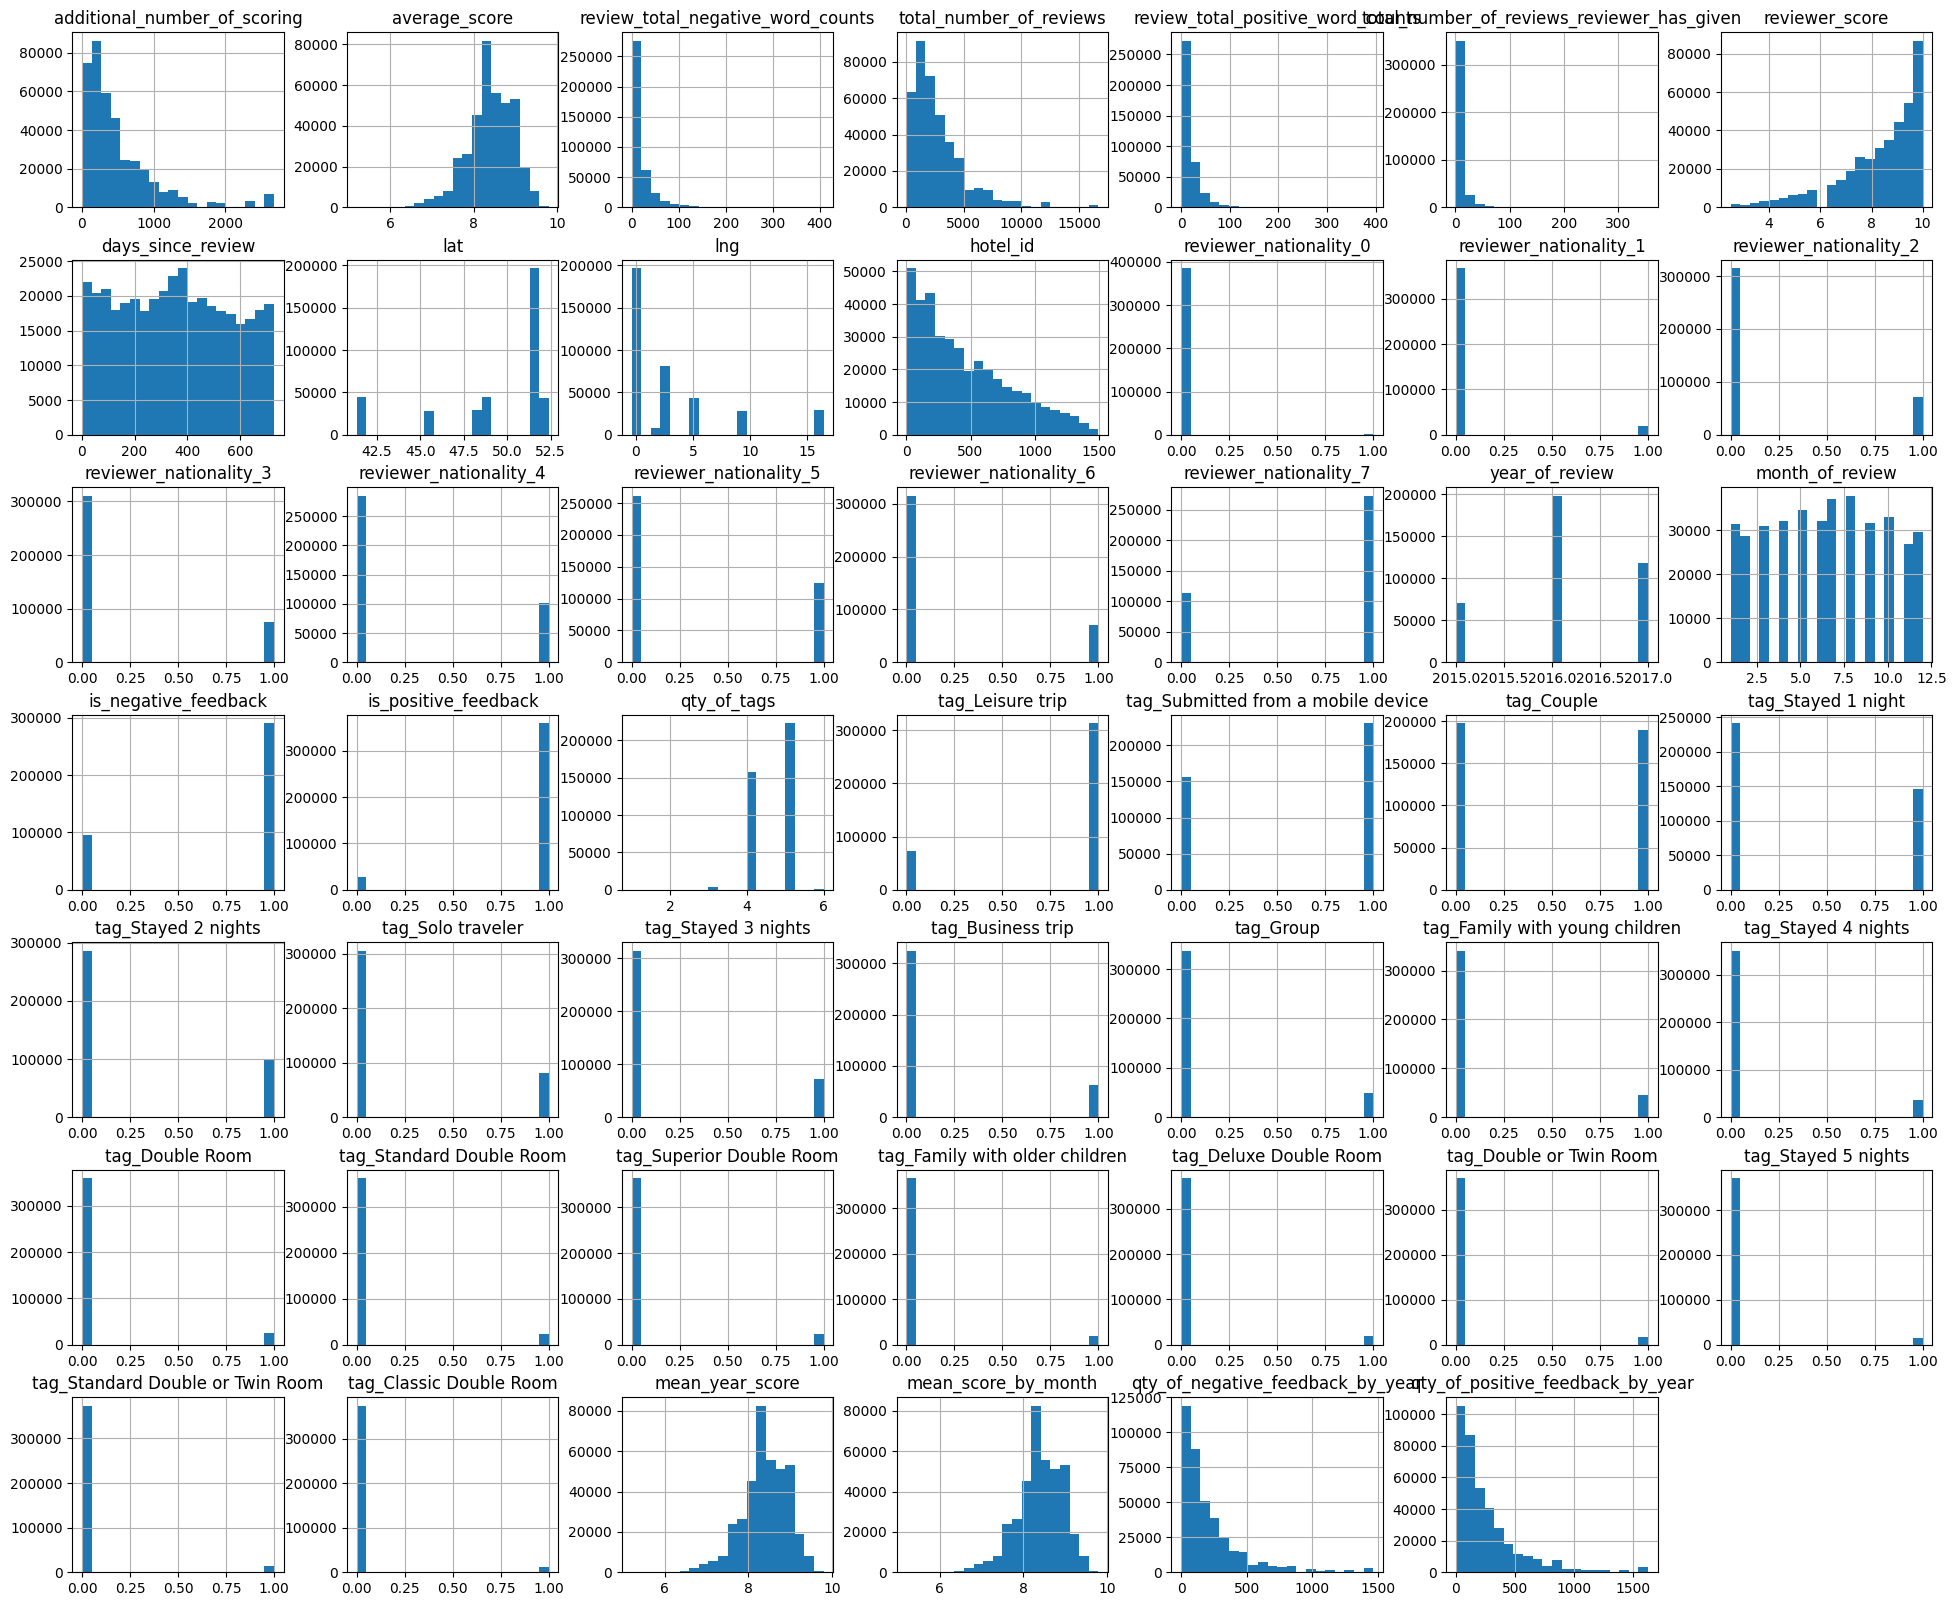

In [37]:
# Visualizing the distribution of all features

hotels_train_filled.hist(bins=20, figsize=(24,20));

In [38]:
# Setting the significance level

alpha = 0.05 
print("Significance level alpha = {:.2f}".format(alpha))

# Function to determine normality

def decision_normality(column):
    _, p_value = stats.kstest(column.dropna(), 'norm', args=(column.mean(), column.std()))
    if p_value < alpha:
        print(f'p-value {p_value:.3f} is less than the significance level {alpha:.2f}. The distribution of feature {column.name} deviates from normal.')
    else:
        print(f'p-value {p_value:.3f} is greater than the significance level {alpha:.2f}. The distribution of feature {column.name} is normal.')
        
for column in hotels_train_filled.columns:
    decision_normality(hotels_train_filled[column])

Significance level alpha = 0.05
p-value 0.000 is less than the significance level 0.05. The distribution of feature additional_number_of_scoring deviates from normal.
p-value 0.000 is less than the significance level 0.05. The distribution of feature average_score deviates from normal.
p-value 0.000 is less than the significance level 0.05. The distribution of feature review_total_negative_word_counts deviates from normal.
p-value 0.000 is less than the significance level 0.05. The distribution of feature total_number_of_reviews deviates from normal.
p-value 0.000 is less than the significance level 0.05. The distribution of feature review_total_positive_word_counts deviates from normal.
p-value 0.000 is less than the significance level 0.05. The distribution of feature total_number_of_reviews_reviewer_has_given deviates from normal.
p-value 0.000 is less than the significance level 0.05. The distribution of feature reviewer_score deviates from normal.
p-value 0.000 is less than the si

### As observed, none of our features exhibit a normal distribution.

In [39]:
# def qq_plot(column):
   
#   stats.probplot(column.dropna(), dist="norm", plot=plt)
#    plt.title(f'Q-Q Plot for {column.name}')
#    plt.show()

# for column in hotels_cleaned.columns:
#   qq_plot(hotels_cleaned[column])

We will create visualizations to explore various relationships between features.

We’ll examine `reviewer scores`, `reviews`, and `the distribution of reviewer scores` based on different factors.

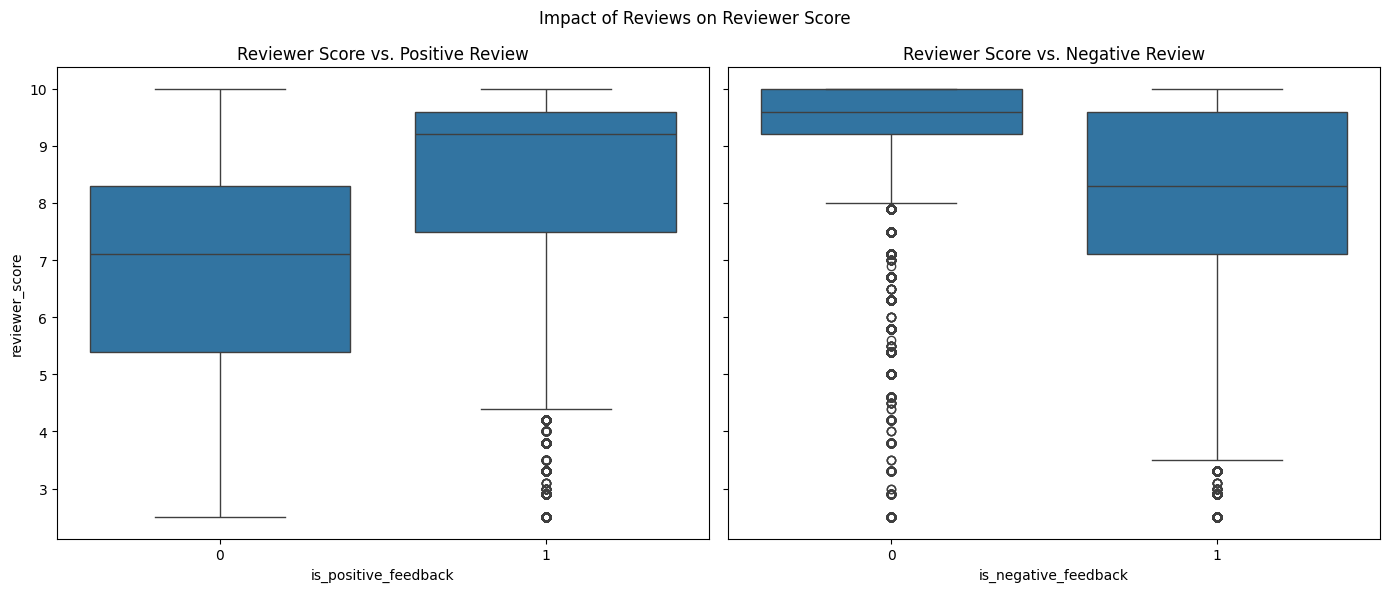

In [40]:
# Visualization of Reviewer Score vs. Reviews (Positive and Negative)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.boxplot(
    data=hotels_train_filled,
    x='is_positive_feedback',
    y='reviewer_score',
    ax=axes[0]
)
axes[0].set_title('Reviewer Score vs. Positive Review')

sns.boxplot(
    data=hotels_train_filled,
    x='is_negative_feedback',
    y='reviewer_score',
    ax=axes[1]
)
axes[1].set_title('Reviewer Score vs. Negative Review')

plt.suptitle('Impact of Reviews on Reviewer Score')
plt.tight_layout()
plt.show()

C:\Users\ademidov\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


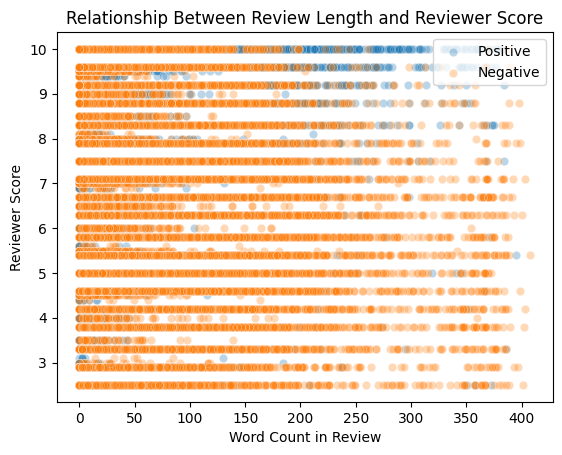

In [41]:
# Visualization of Word Count in Reviews vs. Reviewer Score

sns.scatterplot(
    data=hotels_train_filled,
    x='review_total_positive_word_counts',
    y='reviewer_score',
    alpha=0.3,
    label='Positive'
)
sns.scatterplot(
    data=hotels_train_filled,
    x='review_total_negative_word_counts',
    y='reviewer_score',
    alpha=0.3,
    label='Negative'
)
plt.title('Relationship Between Review Length and Reviewer Score')  
plt.xlabel('Word Count in Review')  
plt.ylabel('Reviewer Score')
plt.legend()
plt.show();

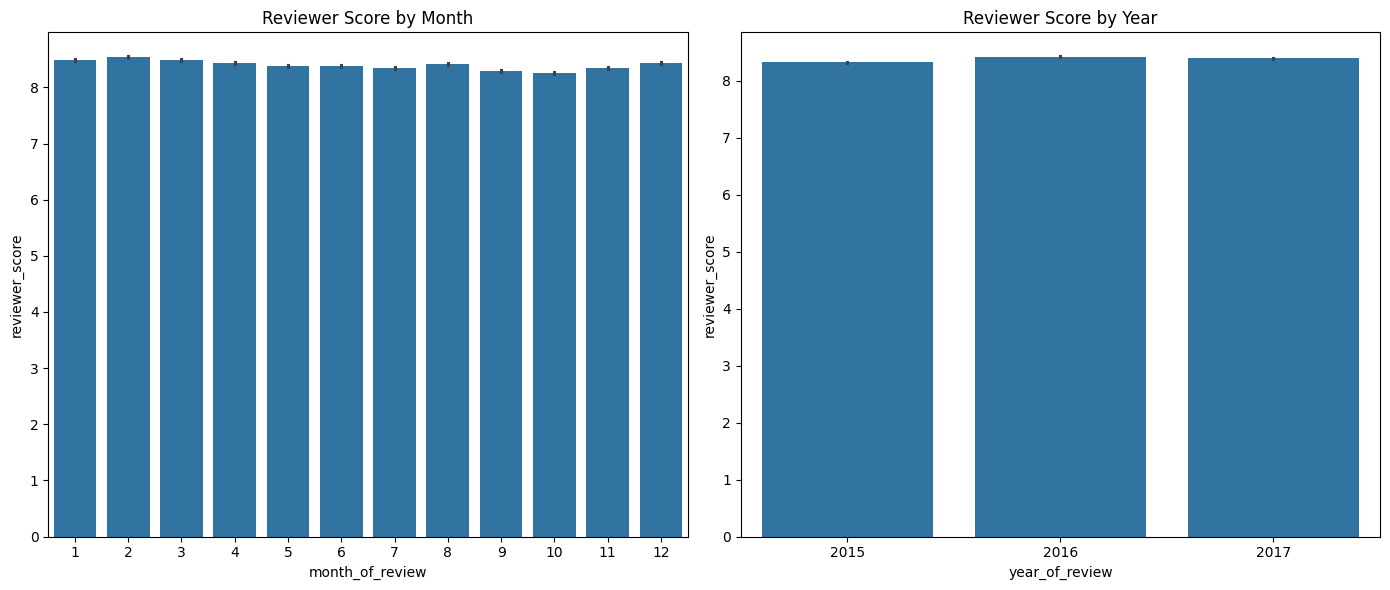

In [42]:
# Visualization of Seasonality: Average Reviewer Score by Month and Year

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=hotels_train_filled,
    x='month_of_review',
    y='reviewer_score',
    ax=ax[0]
)
ax[0].set_title('Reviewer Score by Month')

sns.barplot(
    data=hotels_train_filled,
    x='year_of_review',
    y='reviewer_score',
    ax=ax[1]
)
ax[1].set_title('Reviewer Score by Year')

plt.tight_layout()
plt.show()

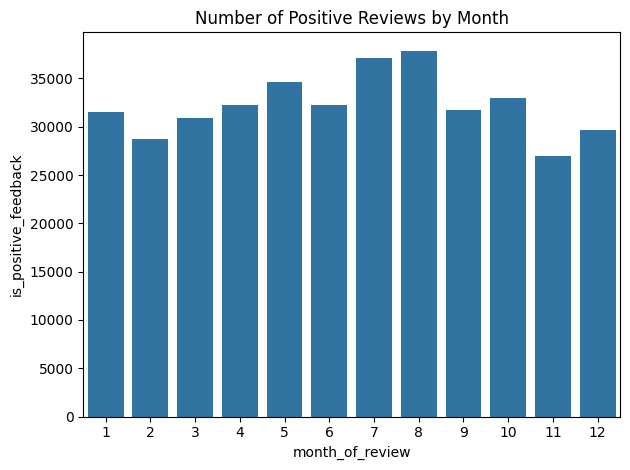

In [43]:
# Examining the number of positive reviews by month

bardata = hotels_train_filled.groupby('month_of_review', as_index=False)['is_positive_feedback'].count()

sns.barplot(
    data=bardata,
    x='month_of_review',
    y='is_positive_feedback'
)
plt.title('Number of Positive Reviews by Month')
plt.tight_layout()
plt.show();

### Conclusions from Visualizations

* Positive reviews are associated with higher ratings, while negative reviews correlate with lower ratings, which is expected.

* There’s a relationship between review length and rating: longer positive reviews tend to accompany higher ratings.

* For negative reviews, this correlation is less pronounced, as review length is more evenly distributed across ratings.

* The highest number of positive reviews occurs in the summer, particularly in July and August, while the fewest are in February and November, possibly due to weather conditions.


## 4. Feature Selection

In [44]:
# Creating the dataset sample

X = hotels_train_filled.drop(['reviewer_score'], axis = 1)  
y = hotels_train_filled['reviewer_score'] 

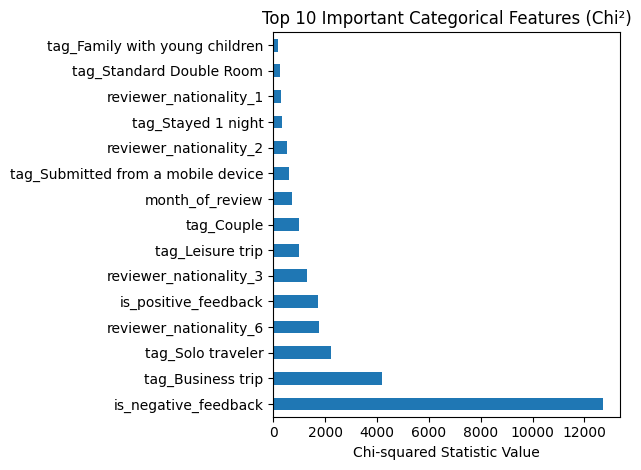

In [45]:
# Selecting the top 10 categorical features

y=y.astype('int')

cat_cols = [
    'reviewer_nationality_0', 'reviewer_nationality_1', 'reviewer_nationality_2', 'reviewer_nationality_3',
    'reviewer_nationality_4', 'reviewer_nationality_5', 'reviewer_nationality_6', 'reviewer_nationality_7', 'year_of_review', 'month_of_review',
    'is_negative_feedback', 'is_positive_feedback', 'tag_Leisure trip', 'tag_Submitted from a mobile device', 'tag_Couple', 'tag_Stayed 1 night',
    'tag_Stayed 2 nights', 'tag_Solo traveler', 'tag_Stayed 3 nights', 'tag_Business trip', 'tag_Group', 'tag_Family with young children', 'tag_Stayed 4 nights',
    'tag_Double Room', 'tag_Standard Double Room', 'tag_Superior Double Room', 'tag_Family with older children', 'tag_Deluxe Double Room', 'tag_Double or Twin Room', 
    'tag_Stayed 5 nights', 'tag_Standard Double or Twin Room', 'tag_Classic Double Room'
]

# Using the Chi-squared test to identify important features and visualizing the results
 
imp_cat = pd.Series(chi2(X[cat_cols], y)[0], index=cat_cols)

imp_cat.sort_values(ascending=False).head(15).plot(kind='barh')
plt.title('Top 10 Important Categorical Features (Chi²)')
plt.xlabel('Chi-squared Statistic Value')
plt.tight_layout()
plt.show();

From the visualization, it’s clear that the **presence of a negative review significantly impacts the rating**. 

Other influential factors include whether the **trip was for business**, whether the **reviewer traveled alone**, and whether a **positive review was provided**. 

Less impactful, but still relevant, are features like the reviewer’s nationality and other tags. We will select the top 10 tags for further model training.

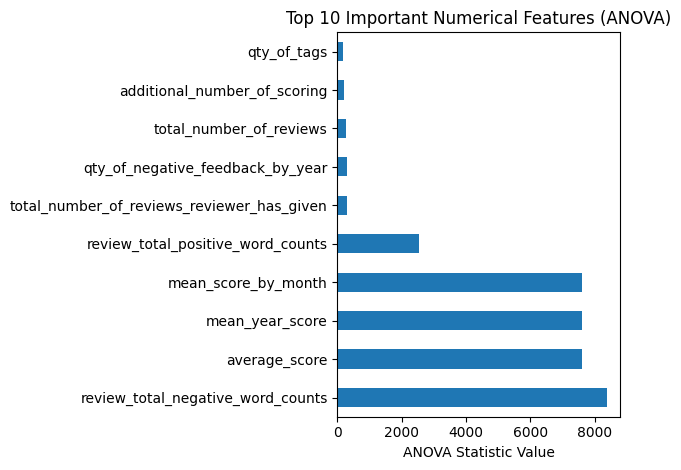

In [46]:
# Selecting the top numerical features

num_cols = [
    'lat', 'lng',
    'average_score',
    'qty_of_tags',
    'mean_year_score',
    'mean_score_by_month',
    'additional_number_of_scoring',
    'review_total_negative_word_counts',
    'review_total_positive_word_counts',
    'total_number_of_reviews',
    'days_since_review',
    'qty_of_negative_feedback_by_year',
    'qty_of_positive_feedback_by_year',
    'total_number_of_reviews_reviewer_has_given'
]

# Using the ANOVA test to determine important features

imp_num = pd.Series(f_classif(X[num_cols], y)[0], index = num_cols)


imp_num.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title('Top 10 Important Numerical Features (ANOVA)')
plt.xlabel('ANOVA Statistic Value')
plt.tight_layout()
plt.show();

Among the most critical features are **the average monthly and yearly ratings**,** the word count in negative reviews**, **the hotel’s average score**, and **the word count in positive reviews**. 

We will select these top 5 features for further model training.

In [47]:
# Compiling the top 15 features for the final dataset

important_cat_features = imp_cat.sort_values(ascending=False).head(5).index.tolist()
important_num_features = imp_num.sort_values(ascending=False).head(5).index.tolist()

imp_features = important_cat_features + important_num_features
print(f'Top 15 features: \n {imp_features}')

Top 15 features: 
 ['is_negative_feedback', 'tag_Business trip', 'tag_Solo traveler', 'reviewer_nationality_6', 'is_positive_feedback', 'review_total_negative_word_counts', 'average_score', 'mean_year_score', 'mean_score_by_month', 'review_total_positive_word_counts']


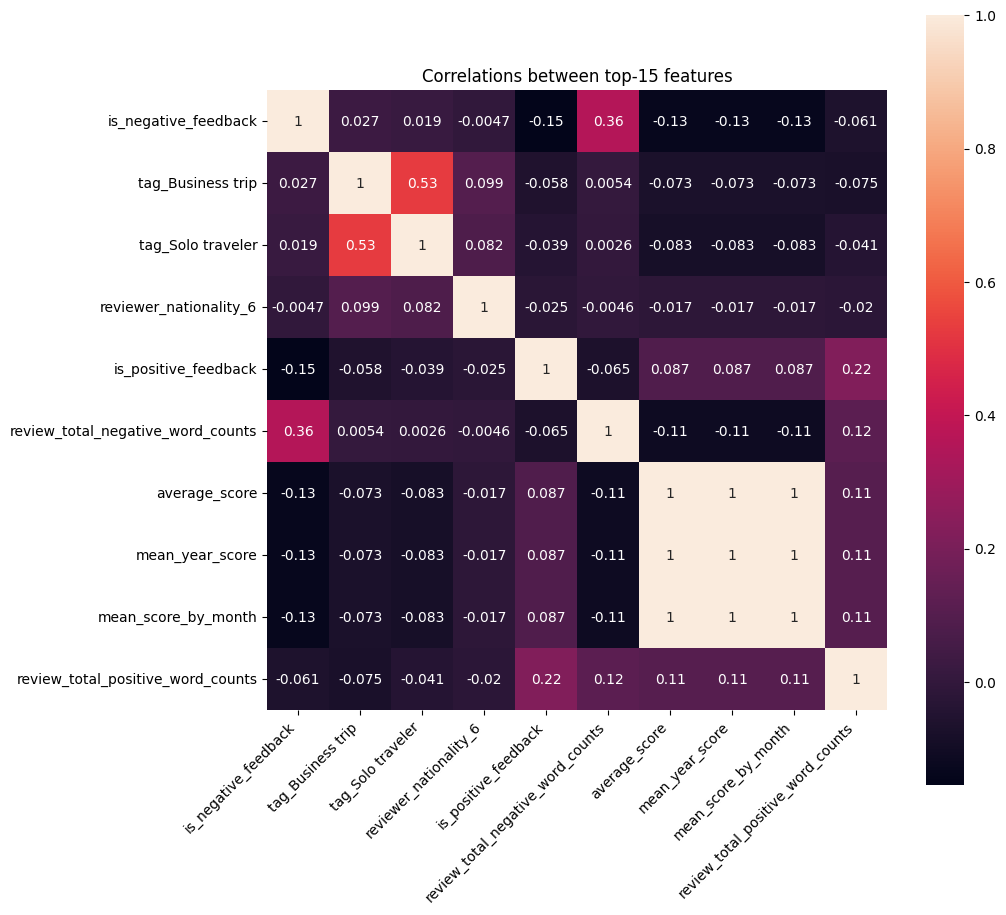

In [48]:
# Building a correlation heatmap

plt.figure(figsize=(10, 10))
ax = sns.heatmap(hotels_train_filled[imp_features].corr(numeric_only=True), annot=True, square=True)
plt.title('Correlations between top-15 features')
plt.xticks(rotation=45, ha='right')
plt.show();

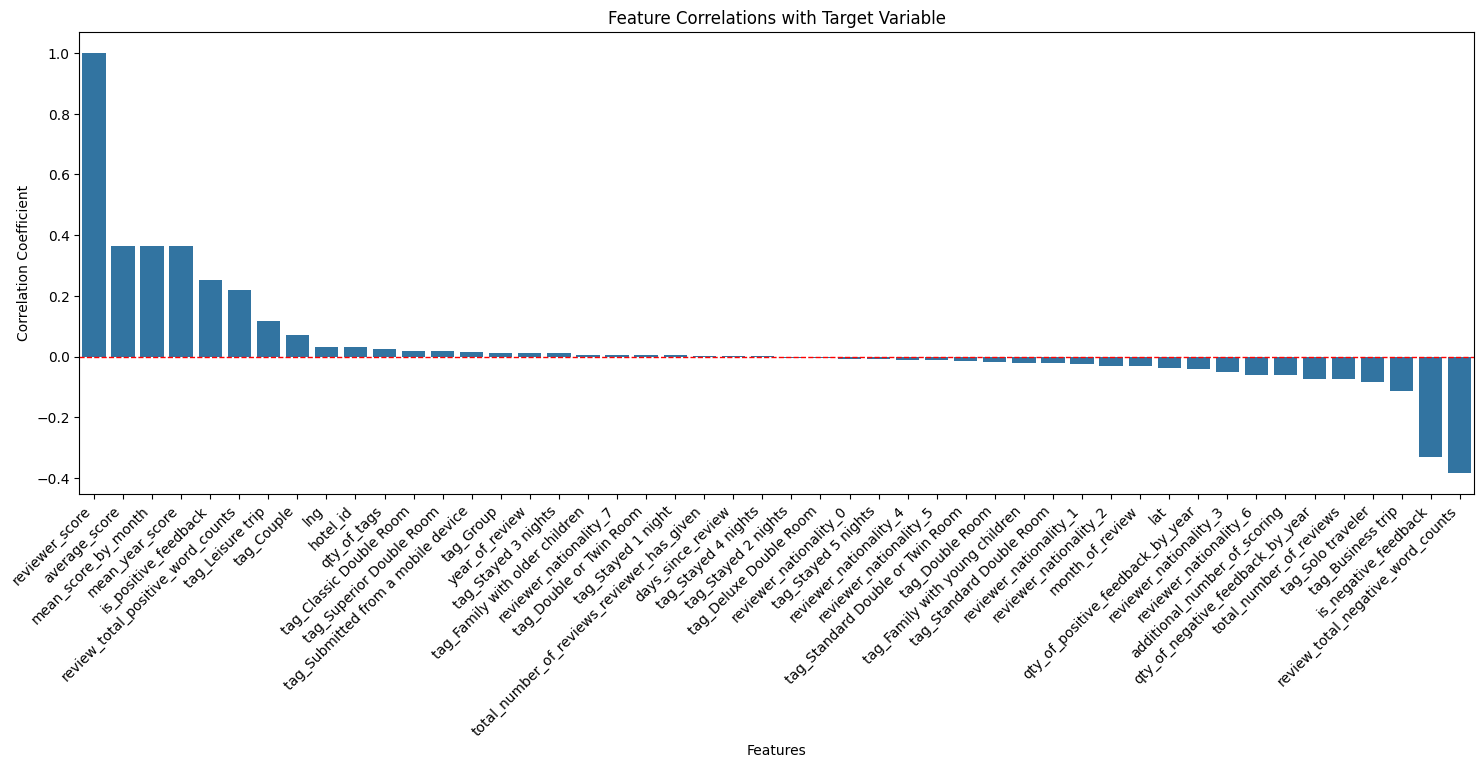

In [49]:
# Plot a bar chart of ranked correlation coefficients for the target feature

correlations = hotels_train_filled.corr()['reviewer_score']
sorted_correlations = correlations.sort_values(ascending=False)

plt.figure(figsize=(18, 6))
sns.barplot(
    x=sorted_correlations.index, 
    y=sorted_correlations.values, 
)
plt.title('Feature Correlations with Target Variable')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xticks(rotation=45, ha='right')

plt.show();

### There is no strong correlation between the target variable and the other features. We can proceed to model training.

In [50]:
# Re-defining X and y

X = hotels_train_filled[imp_features]
y = hotels_train_filled['reviewer_score'] 

In [51]:
# Defining the test dataset with the same features

test_data = hotels_test_filled[imp_features]

In [52]:
# Datasets labeled "train" will be used for training the model, while "test" datasets will be used for testing.
# For testing, we will use 25% of the original dataset.

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, random_state=42)

In [53]:
# find top 25 features using SelectKBest

#selector = SelectKBest(k=10, score_func=f_regression)

#selector.fit(X_train, y_train)
#best_features = selector.get_feature_names_out().tolist()
#print(f'Features selected for further model building: \n {selector.get_feature_names_out()}')

# Transform the training and validation sets using the selector

#X_train_selected = selector.transform(X_train)
#X_test_selected = selector.transform(X_test)
#data_selected = selector.transform(test_data)

In [54]:
# Initializing the StandardScaler for standardization

scaler = preprocessing.StandardScaler()

# Standardizing the data

scaler.fit(X_train)
X_scaled_train = scaler.transform(X_train)
X_scaled_test = scaler.transform(X_test)
test_data_scaled = scaler.transform(test_data)

## 5. Model Fitting

In [59]:
start_time = time.time()
  
# Creating the model 

regr = ensemble.RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)  
      
# Training the model on the train dataset

regr.fit(X_scaled_train, y_train)  
      
# Using the trained model to predict hotel ratings in both the test and training datasets. 
# Storing the predicted values in the variable y_pred

y_pred_train = regr.predict(X_scaled_train)  
y_pred_test = regr.predict(X_scaled_test)  

# Comparing the predicted values (y_pred) with the actual values (y_test) to evaluate their differences
# The metric used is Mean Absolute Percentage Error (MAPE), which measures the average absolute percentage error between predicted and actual values

mape_train = metrics.mean_absolute_percentage_error(y_train, y_pred_train)
mape_test = metrics.mean_absolute_percentage_error(y_test, y_pred_test)

print(f'MAPE for the training dataset: {mape_train:.5f}')
print(f'MAPE for the test dataset: {mape_test:.5f}')
print()
print(f'Time spent training the model: {time.time() - start_time:.2f} seconds')

MAPE for the training dataset: 0.13230
MAPE for the test dataset: 0.13453

Time spent training the model: 7.54 seconds


### Conclusion

* The initial result, after basic dataset preprocessing (at the first stage, we simply removed columns containing object and string data types and filled missing values with a single value, such as "unknown," zero, or the column’s mean), `yielded a MAPE of 0.1413`.

* After further data processing, feature engineering, creating new features, and selecting the most important ones, we improved the model’s performance, **`achieving a MAPE of 0.13453 on the test set`**.

## 6. Submission

In [56]:

# Predicting the hotel ratings for the test dataset

test_data_pred = regr.predict(test_data_scaled)

# Make a submission

submission = pd.read_csv('data/submission.csv')
submission['reviewer_score'] = test_data_pred
submission.head()


,reviewer_score,id
0,8.551833,488440
1,7.716372,274649
2,8.254620,374688
3,9.678527,404352
4,9.562091,451596


In [57]:
# Check dimensions of test datasets at different stages

print(f"Rows in hotels_test.csv: {len(pd.read_csv('data/hotels_test.csv'))}")
print(f"Rows in hotels_test_filled: {len(hotels_test_filled)}")
print(f"Rows in submission.csv: {len(pd.read_csv('data/submission.csv'))}")
print(f"Length of test_data_pred: {len(test_data_pred)}")

Rows in hotels_test.csv: 128935
Rows in hotels_test_filled: 128935
Rows in submission.csv: 128935
Length of test_data_pred: 128935


In [58]:
# write a file with submissions 

submission.to_csv('data/submission_v1.csv', index=False)